## Project Overview
Lloyds subsidiary, SmartBank, is experiencing increased customer churn, especially among young professionals and small business owners.

**The Goal:** Develop a predictive model to identify customers at risk of leaving (churn).

**Client Need:** SmartBank needs to identify at-risk customers so they can implement targeted actions to keep them.

**Impact:** Successful prediction and intervention can significantly improve SmartBank's customer retention and profitability.

Role info:
- A new data scientist at Lloyds Banking Group, work in the Data Science & Analytics team.
- The team wants to use data to help keep customers from leaving (customer retention).
- Task is to predict which customers might leave (customer churn).

Goal:
- To collaborate with the team to gather and analyse data relevant to customer churn.
- To perform exploratory data analysis to uncover patterns and insights, clean and preprocess the data, and build a predictive model for customer churn.
- To suggest ways to evaluate and measure the model's performance.

### **Key concepts**
**Customer churn:** The process by which customers stop doing business with a company. Identifying and preventing churn is crucial for maintaining a stable customer base.

**Predictive analytics:** Techniques that use historical data to forecast future possibilities. In this project, you'll use predictive analytics to predict which customers are likely to churn.

**Exploratory data analysis (EDA):** A method of analysing data sets to summarise their primary characteristics, often using visual strategies. EDA is crucial for understanding the data before building predictive models.

**Machine learning models:** Algorithms that let computers learn from and make predictions or decisions based on data. You'll be building a classification model to predict customer churn.

## Phase 1: Data gathering and exploratory analysis
Objective: Collect relevant data, perform exploratory data analysis (EDA), and prepare the data for modelling.
Steps:
Identify and gather data from provided sources relevant to predicting customer churn.
Conduct EDA to understand the data, identify key features, and uncover patterns and insights.
Clean and preprocess the data to ensure it is ready for model building.
Deliverable: Submit a report detailing your exploratory data analysis and key findings, including the cleaned and preprocessed data set.


1. Identify and gather data:
2. Perform EDA:
3. Clean and preprocess the data:
4. File submission:


In [1]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
file_path = '/content/.../04 Lloyds bank /Customer_Churn_Data_Large.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# read differnt sheet under file_path

import pandas as pd

def read_sheet_from_excel(file_path, sheet_name):
  """Reads a specific sheet from an Excel file.

  Args:
    file_path: The path to the Excel file.
    sheet_name: The name of the sheet to read.

  Returns:
    A pandas DataFrame containing the data from the specified sheet,
    or None if an error occurs.
  """
  try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df
  except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'")
    return None
  except ValueError:
    print(f"Error: Sheet '{sheet_name}' not found in the Excel file.")
    return None
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    return None

# Read sheets
customer = read_sheet_from_excel(file_path, 'Customer_Demographics')
transaction = read_sheet_from_excel(file_path, 'Transaction_History')
service = read_sheet_from_excel(file_path, 'Customer_Service')
activity = read_sheet_from_excel(file_path, 'Online_Activity')
churn = read_sheet_from_excel(file_path, 'Churn_Status')

In [4]:
#  dimension of the datasets
print("Customer Demographics shape:", customer.shape)
print("Transaction History shape:", transaction.shape)
print("Customer Service shape:", service.shape)
print("Online Activity shape:", activity.shape)
print("Churn Status shape:", churn.shape)


Customer Demographics shape: (1000, 5)
Transaction History shape: (5054, 5)
Customer Service shape: (1002, 5)
Online Activity shape: (1000, 4)
Churn Status shape: (1000, 2)


In [5]:
# Display info for each dataframe
print("\nCustomer Demographics Info:")
customer.info()

print("\nTransaction History Info:")
transaction.info()

print("\nCustomer Service Info:")
service.info()

print("\nOnline Activity Info:")
activity.info()

print("\nChurn Status Info:")
churn.info()


Customer Demographics Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB

Transaction History Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: da

In [6]:
# Display the head of each dataframe
print("Customer Demographics head:")
print(customer.head())

print("\nTransaction History head:")
print(transaction.head())

print("\nCustomer Service head:")
print(service.head())

print("\nOnline Activity head:")
print(activity.head())

print("\nChurn Status head:")
print(churn.head())


Customer Demographics head:
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium

Transaction History head:
   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing

Customer Service head:
   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1        

In [7]:
# Descriptive statistics for numerical features in the 'customer' dataframe
print("\nDescriptive Statistics for Customer Demographics:")
print(customer.describe().T)

# Descriptive statistics for numerical features in the 'transaction' dataframe
print("\nDescriptive Statistics for Transaction History:")
print(transaction.describe().T)

# Descriptive statistics for numerical features in the 'service' dataframe
print("\nDescriptive Statistics for Customer Service:")
print(service.describe().T)

# Descriptive statistics for numerical features in the 'activity' dataframe
print("\nDescriptive Statistics for Online Activity:")
print(activity.describe().T)

# we can use value_counts to see the distribution of churn.
print("\nChurn Status Distribution:")
print(churn['ChurnStatus'].value_counts().T)


Descriptive Statistics for Customer Demographics:
             count     mean         std   min     25%    50%     75%     max
CustomerID  1000.0  500.500  288.819436   1.0  250.75  500.5  750.25  1000.0
Age         1000.0   43.267   15.242311  18.0   30.00   43.0   56.00    69.0

Descriptive Statistics for Transaction History:
                  count                           mean                  min  \
CustomerID       5054.0                     501.424218                  1.0   
TransactionID    5054.0                    5510.538979               1000.0   
TransactionDate    5054  2022-07-01 19:25:37.158686208  2022-01-01 00:00:00   
AmountSpent      5054.0                     250.707351                 5.18   

                                 25%                  50%  \
CustomerID                     251.0                506.0   
TransactionID                 3242.0               5530.0   
TransactionDate  2022-04-03 00:00:00  2022-07-01 00:00:00   
AmountSpent                  

In [8]:
# check each sheet to see if any missing values

def check_missing_values(df, sheet_name):
  """Checks for missing values in a DataFrame and prints the results.

  Args:
    df: The pandas DataFrame to check.
    sheet_name: The name of the sheet the DataFrame originates from.
  """
  missing_values = df.isnull().sum()
  print(f"\nMissing values in '{sheet_name}':")
  if missing_values.sum() == 0:
    print("No missing values found.")
  else:
    print(missing_values[missing_values > 0])


# Call the function for each DataFrame
check_missing_values(customer, 'Customer_Demographics')
check_missing_values(transaction, 'Transaction_History')
check_missing_values(service, 'Customer_Service')
check_missing_values(activity, 'Online_Activity')
check_missing_values(churn, 'Churn_Status')



Missing values in 'Customer_Demographics':
No missing values found.

Missing values in 'Transaction_History':
No missing values found.

Missing values in 'Customer_Service':
No missing values found.

Missing values in 'Online_Activity':
No missing values found.

Missing values in 'Churn_Status':
No missing values found.


In [9]:
# check each sheet for duplicate records

def check_duplicates(df, sheet_name):
    """Checks for duplicate rows in a DataFrame and prints the results.

    Args:
        df: The pandas DataFrame to check.
        sheet_name: The name of the sheet the DataFrame originates from.
    """
    duplicates = df[df.duplicated(keep=False)]
    print(f"\nDuplicate rows in '{sheet_name}':")
    if duplicates.empty:
        print("No duplicate rows found.")
    else:
        print(duplicates)

# Call the function for each DataFrame
check_duplicates(customer, 'Customer_Demographics')
check_duplicates(transaction, 'Transaction_History')
check_duplicates(service, 'Customer_Service')
check_duplicates(activity, 'Online_Activity')
check_duplicates(churn, 'Churn_Status')



Duplicate rows in 'Customer_Demographics':
No duplicate rows found.

Duplicate rows in 'Transaction_History':
No duplicate rows found.

Duplicate rows in 'Customer_Service':
No duplicate rows found.

Duplicate rows in 'Online_Activity':
No duplicate rows found.

Duplicate rows in 'Churn_Status':
No duplicate rows found.


In [10]:
# Merge datasets together to get a final data

# Merge the datasets based on the common column 'CustomerID'
merged_df = pd.merge(customer, transaction, on='CustomerID', how='outer')
merged_df = pd.merge(merged_df, service, on='CustomerID', how='outer')
merged_df = pd.merge(merged_df, activity, on='CustomerID', how='outer')
merged_df = pd.merge(merged_df, churn, on='CustomerID', how='outer')

# Now 'merged_df' contains the combined data
print("Merged Data shape:", merged_df.shape)
merged_df.head()

Merged Data shape: (6812, 17)


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [11]:
# Convert 'InteractionID' to string and remove decimals
merged_df['InteractionID'] = merged_df['InteractionID'].astype(str)
merged_df['InteractionID'] = merged_df['InteractionID'].str.split('.').str[0]
merged_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [12]:
# Check for duplicates in the merged DataFrame
duplicates = merged_df[merged_df.duplicated(keep=False)]
print(f"\nDuplicate rows in 'merged_df':")
if duplicates.empty:
    print("No duplicate rows found.")
else:
    print(duplicates)

# Drop duplicate rows
merged_df = merged_df.drop_duplicates()
print("\nShape of merged_df after removing duplicates:", merged_df.shape)



Duplicate rows in 'merged_df':
No duplicate rows found.

Shape of merged_df after removing duplicates: (6812, 17)


In [13]:
# check merged_df for missing values
check_missing_values(merged_df, 'Merged Data')

# check merged_df for duplicates
check_duplicates(merged_df, 'Merged Data')



Missing values in 'Merged Data':
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
dtype: int64

Duplicate rows in 'Merged Data':
No duplicate rows found.


In [14]:
#return a dataframe with those missing values

def get_missing_values_df(df):
  """Returns a DataFrame containing only rows with missing values."""
  missing_rows = df[df.isnull().any(axis=1)]
  return missing_rows

missing_values_df = get_missing_values_df(merged_df)
missing_values_df


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
24,5,21,M,Divorced,Medium,1742,2022-02-21,475.69,Groceries,nan,NaT,NaN,NaN,2023-10-27,41,Website,0
25,5,21,M,Divorced,Medium,9349,2022-08-12,178.91,Furniture,nan,NaT,NaN,NaN,2023-10-27,41,Website,0
26,5,21,M,Divorced,Medium,7200,2022-12-02,373.51,Groceries,nan,NaT,NaN,NaN,2023-10-27,41,Website,0
27,5,21,M,Divorced,Medium,4938,2022-10-21,155.76,Electronics,nan,NaT,NaN,NaN,2023-10-27,41,Website,0
28,5,21,M,Divorced,Medium,5357,2022-07-04,308.80,Electronics,nan,NaT,NaN,NaN,2023-10-27,41,Website,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,34,M,Widowed,Low,2724,2022-09-08,232.06,Groceries,nan,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6808,1000,34,M,Widowed,Low,2917,2022-12-13,324.98,Books,nan,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6809,1000,34,M,Widowed,Low,2979,2022-06-15,375.34,Groceries,nan,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6810,1000,34,M,Widowed,Low,8594,2022-04-08,166.73,Books,nan,NaT,NaN,NaN,2023-08-13,22,Mobile App,0


### Exploratory Data Analysis (EDA) for Merged Data:

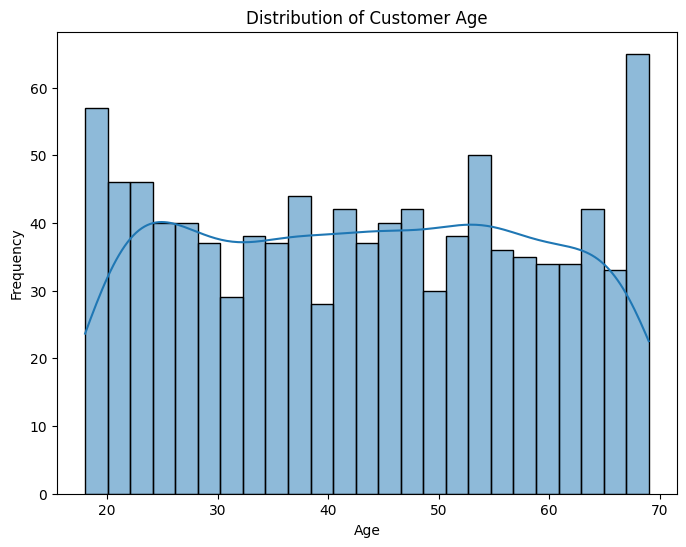

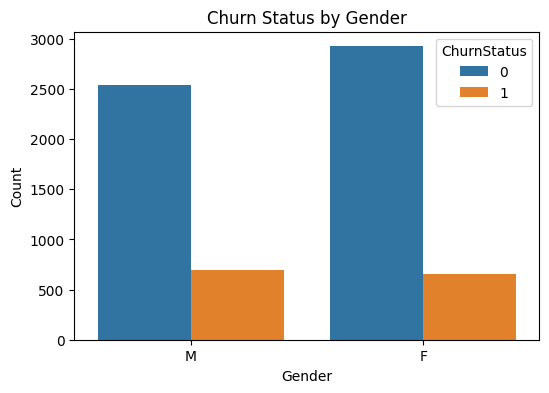

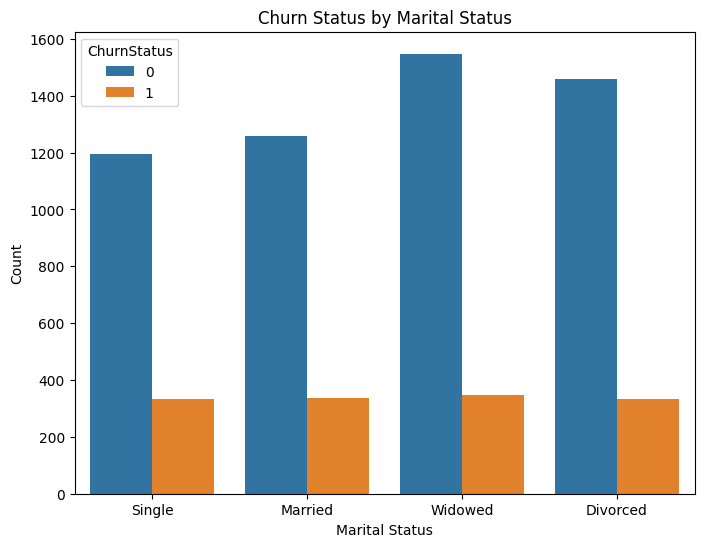

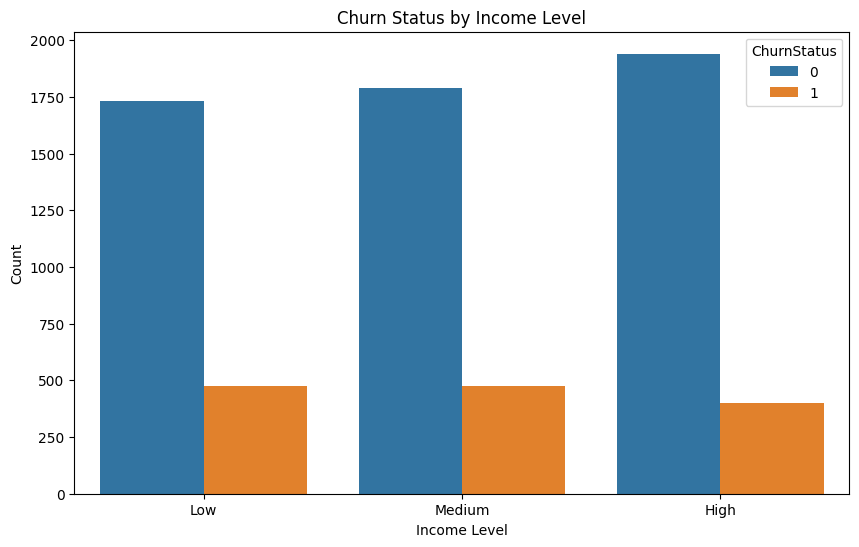

In [15]:
#data visulatiozation with customer age; gender ;marital status and income level with churn status

# Visualize the distribution of customer age
plt.figure(figsize=(8, 6))
sns.histplot(customer['Age'], bins=25, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Visualize the relationship between gender and churn status
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Visualize the relationship between marital status and churn status
plt.figure(figsize=(8, 6))
sns.countplot(x='MaritalStatus', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

# Visualize the relationship between income level and churn status
plt.figure(figsize=(10, 6))
sns.countplot(x='IncomeLevel', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()

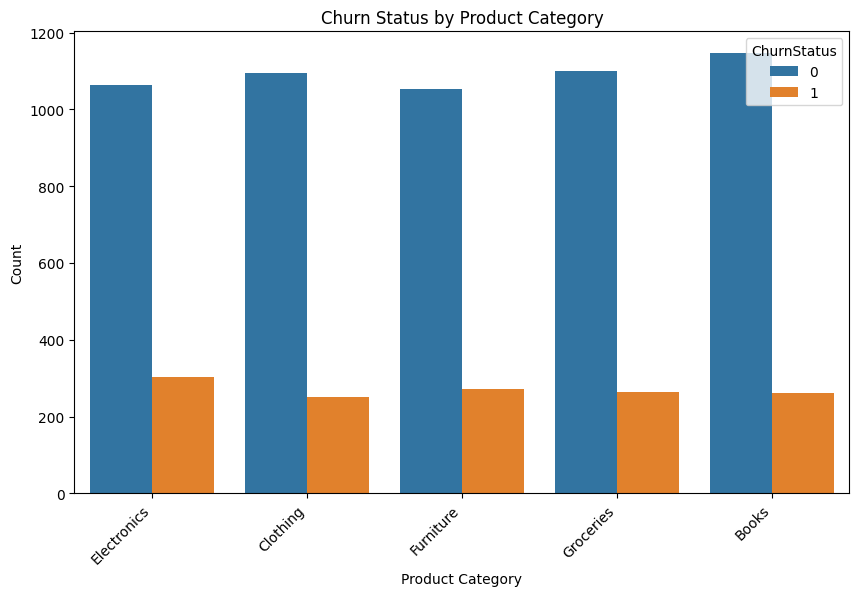

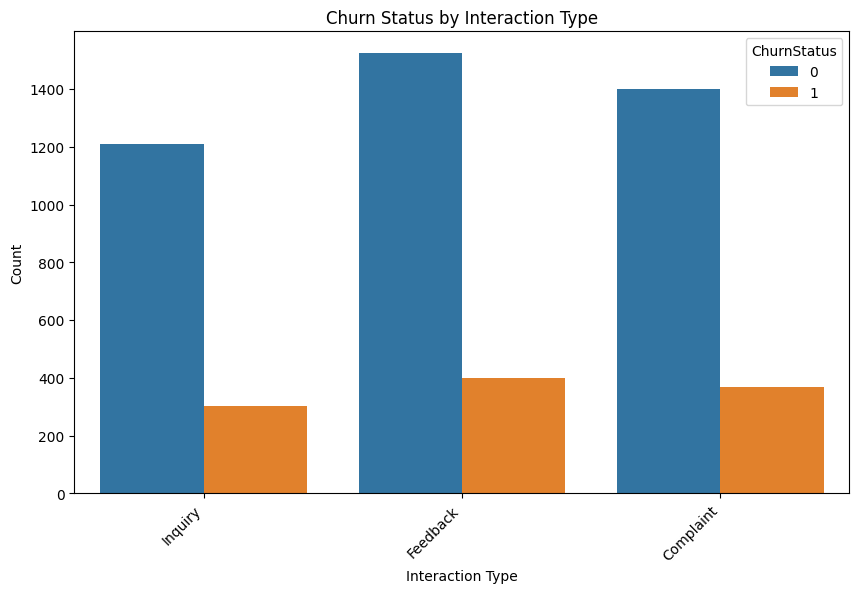

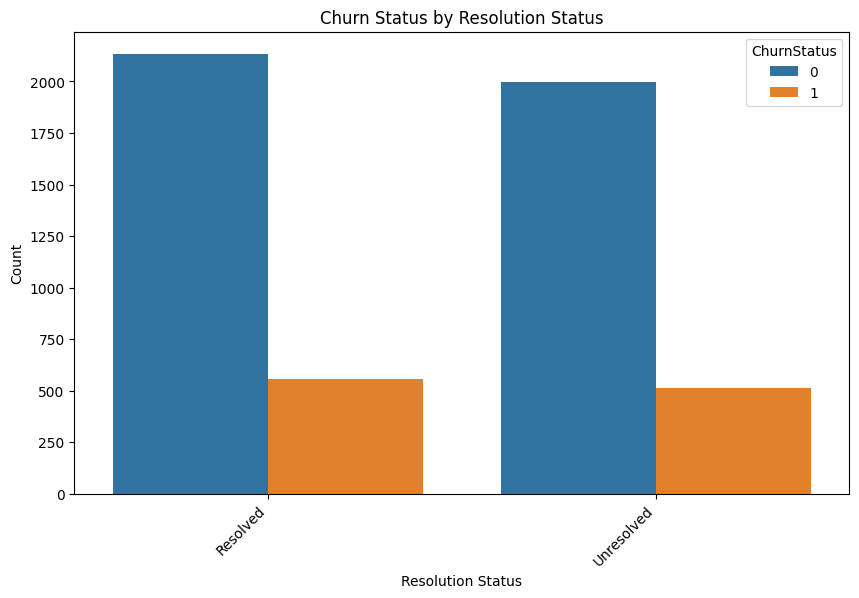

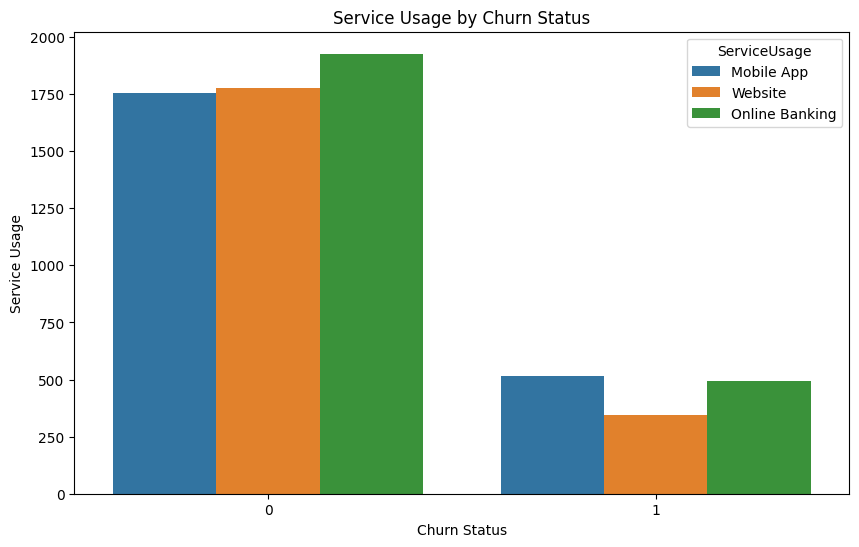

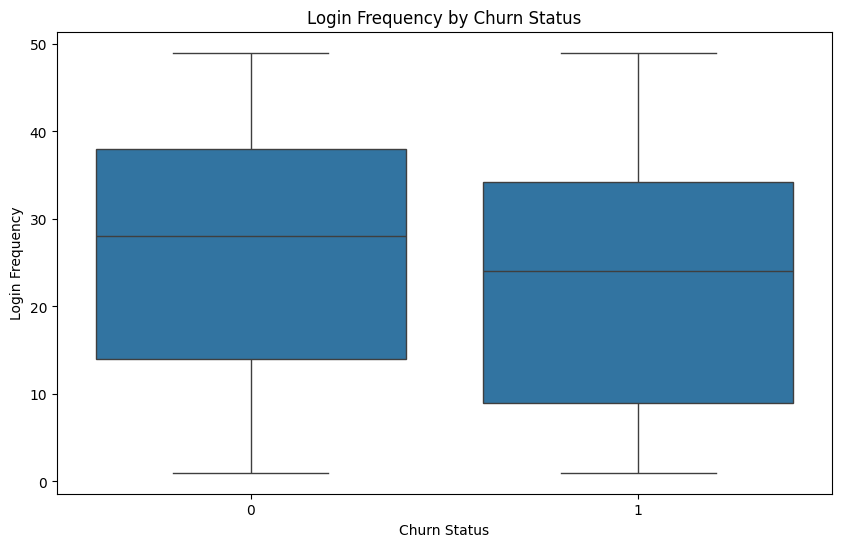

In [16]:
# visulaize ProductCategory; InteractionType; ResolutionStatus; ServiceUsage ; login frequency and churn status

import matplotlib.pyplot as plt
# Visualize the relationship between ProductCategory and churn status
plt.figure(figsize=(10, 6))
sns.countplot(x='ProductCategory', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.show()

# Visualize the relationship between InteractionType and churn status
plt.figure(figsize=(10, 6))
sns.countplot(x='InteractionType', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Interaction Type')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualize the relationship between ResolutionStatus and churn status
plt.figure(figsize=(10, 6))
sns.countplot(x='ResolutionStatus', hue='ChurnStatus', data=merged_df)
plt.title('Churn Status by Resolution Status')
plt.xlabel('Resolution Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualize the relationship between ServiceUsage and churn status
plt.figure(figsize=(10, 6))
sns.countplot(x='ChurnStatus', hue='ServiceUsage', data=merged_df)
plt.title('Service Usage by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Service Usage')
plt.show()


# Visualize the relationship between login frequency and churn status
plt.figure(figsize=(10, 6))
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=merged_df)
plt.title('Login Frequency by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Login Frequency')
plt.show()


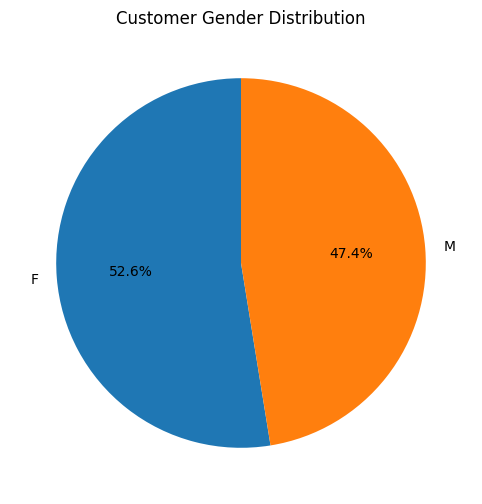

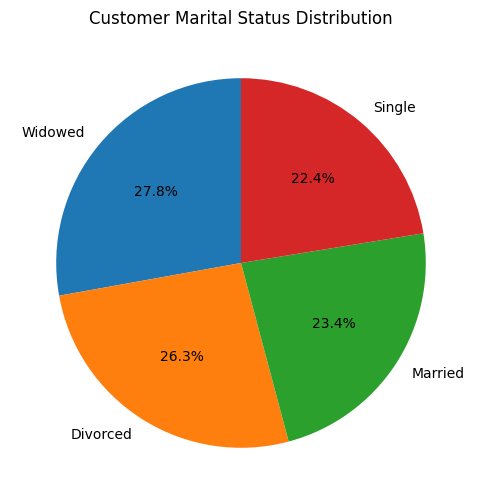

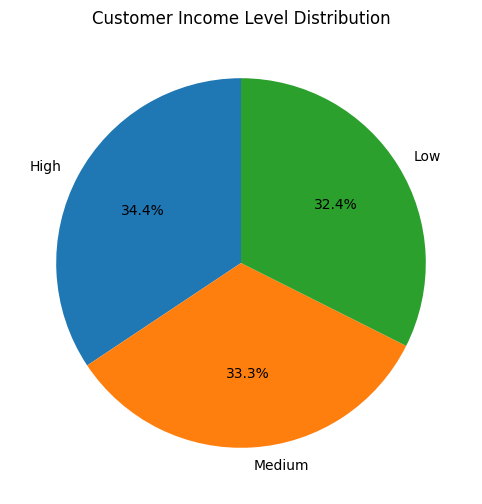

In [17]:
# Visualize customer gender distribution
plt.figure(figsize=(8, 6))
merged_df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Customer Gender Distribution')
plt.ylabel('')  # Remove the y-axis label
plt.show()

# Visualize customer marital status distribution
plt.figure(figsize=(8, 6))
merged_df['MaritalStatus'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Customer Marital Status Distribution')
plt.ylabel('')  # Remove the y-axis label
plt.show()

# Visualize customer income level distribution
plt.figure(figsize=(8, 6))
merged_df['IncomeLevel'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Customer Income Level Distribution')
plt.ylabel('')  # Remove the y-axis label
plt.show()


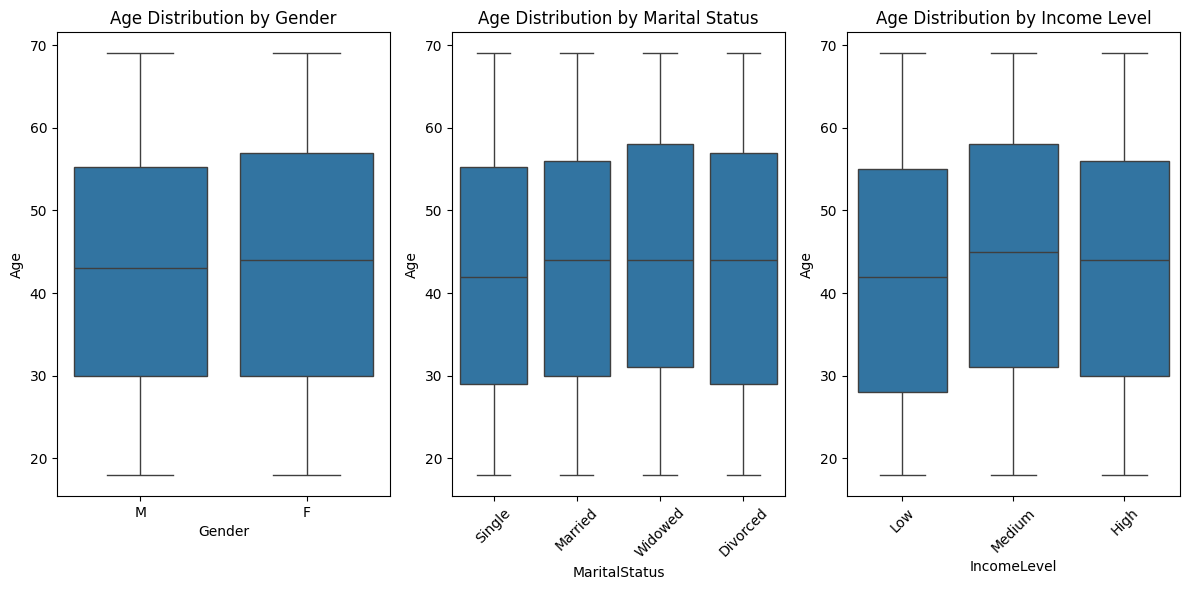

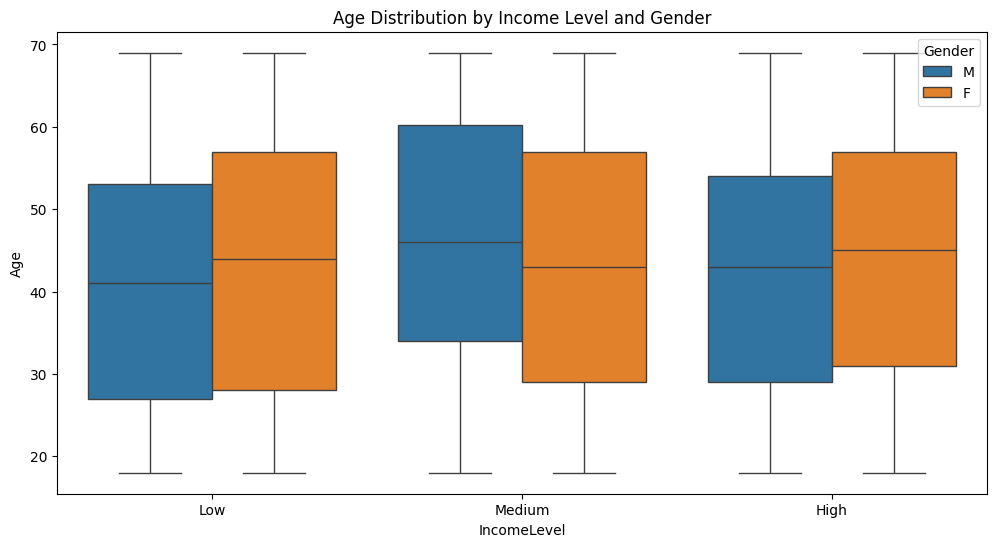

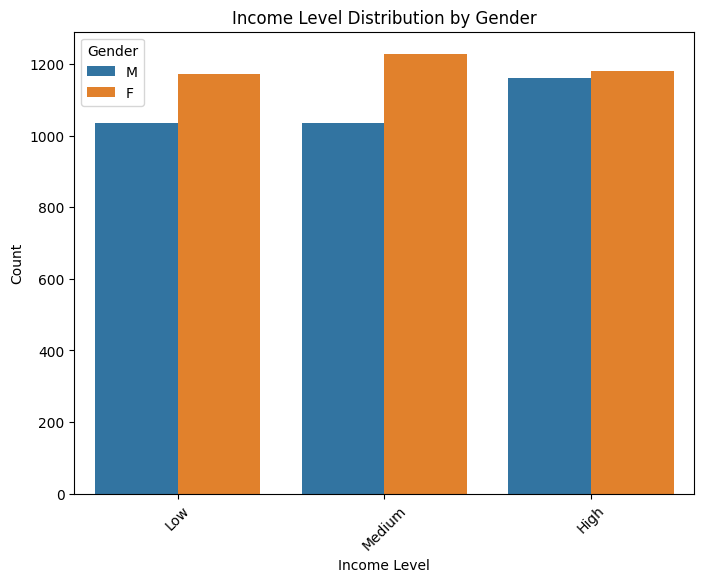

IncomeLevel         High        Low     Medium
MaritalStatus                                 
Divorced       42.360714  40.201268  48.393688
Married        44.996454  41.568480  43.622490
Single         42.370107  42.652074  42.327068
Widowed        43.085627  44.633826  42.819905


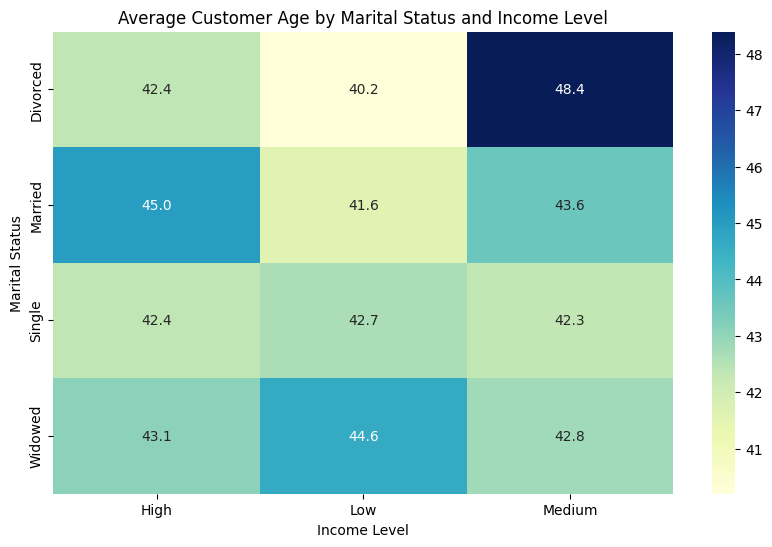

In [18]:
# Boxplot: Age Distribution by Gender;  Age Distribution by Marital Status;Age Distribution by Income Level;
# Countplot: Income Level Distribution by Gender

# Boxplots
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='Gender', y='Age', data=merged_df)
plt.title('Age Distribution by Gender')

plt.subplot(1, 3, 2)
sns.boxplot(x='MaritalStatus', y='Age', data=merged_df)
plt.title('Age Distribution by Marital Status')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.subplot(1, 3, 3)
sns.boxplot(x='IncomeLevel', y='Age', data=merged_df)
plt.title('Age Distribution by Income Level')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()

# Boxplot: Age distribution by Income Level, Gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='IncomeLevel', y='Age', hue='Gender', data=merged_df)
plt.title('Age Distribution by Income Level and Gender')
plt.show()

# Countplot
plt.figure(figsize=(8, 6))
sns.countplot(x='IncomeLevel', hue='Gender', data=merged_df)
plt.title('Income Level Distribution by Gender')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Create the pivot table
pivot_table_age = pd.pivot_table(merged_df, index='MaritalStatus', columns='IncomeLevel', values='Age', aggfunc='mean')

# Display the pivot table
print(pivot_table_age)

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_age, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Average Customer Age by Marital Status and Income Level')
plt.xlabel('Income Level')
plt.ylabel('Marital Status')
plt.show()


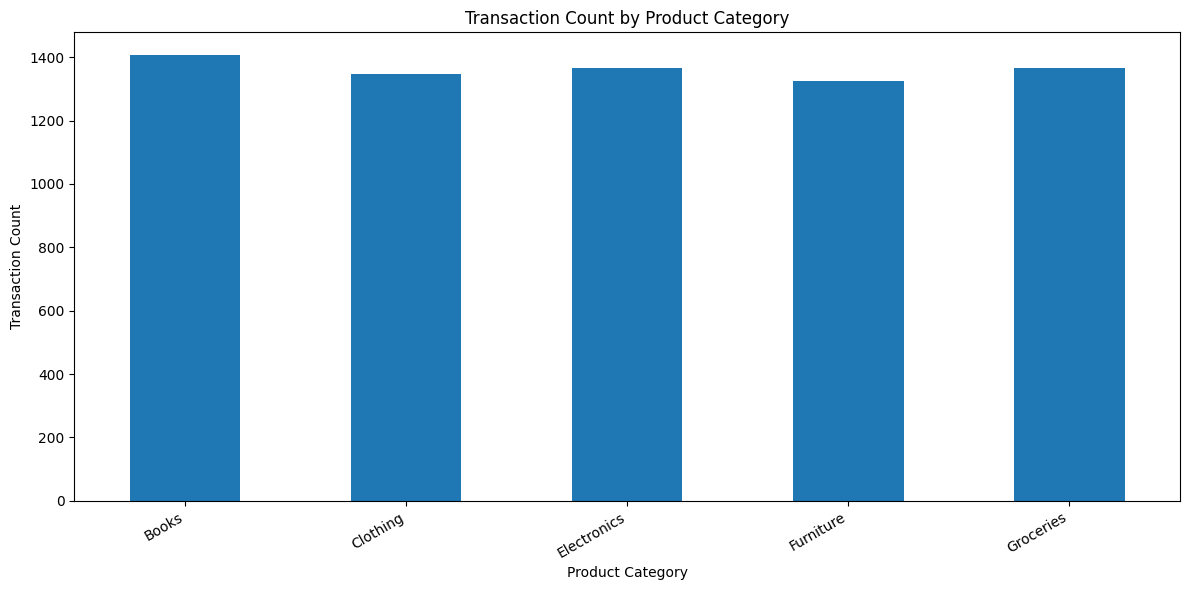

In [19]:
# Calculate transaction count by product category
transaction_counts = merged_df.groupby('ProductCategory')['TransactionID'].count()

# Create a bar plot
plt.figure(figsize=(12, 6))
transaction_counts.plot(kind='bar')
plt.title('Transaction Count by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Transaction Count')
plt.xticks(rotation=30, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


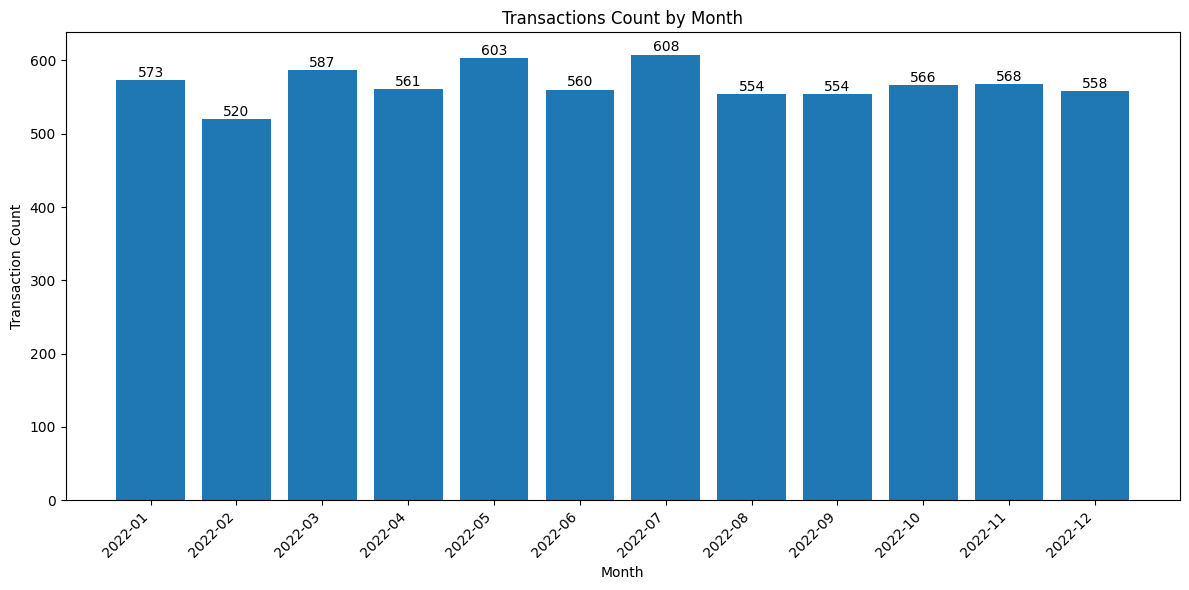

In [20]:
#Calculate transaction count by Month; and plot

# Convert the 'TransactionDate' column to datetime objects
merged_df['TransactionDate'] = pd.to_datetime(merged_df['TransactionDate'])

# Extract the month from the 'TransactionDate' column
merged_df['TransactionMonth'] = merged_df['TransactionDate'].dt.to_period('M')

# Calculate transaction count by month
transaction_counts_by_month = merged_df.groupby('TransactionMonth')['TransactionID'].count()

# Create the plot
plt.figure(figsize=(12, 6))
bars = plt.bar(transaction_counts_by_month.index.astype(str), transaction_counts_by_month.values)
plt.title('Transactions Count by Month')
plt.xlabel('Month')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45, ha='right')

# Add value labels above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()


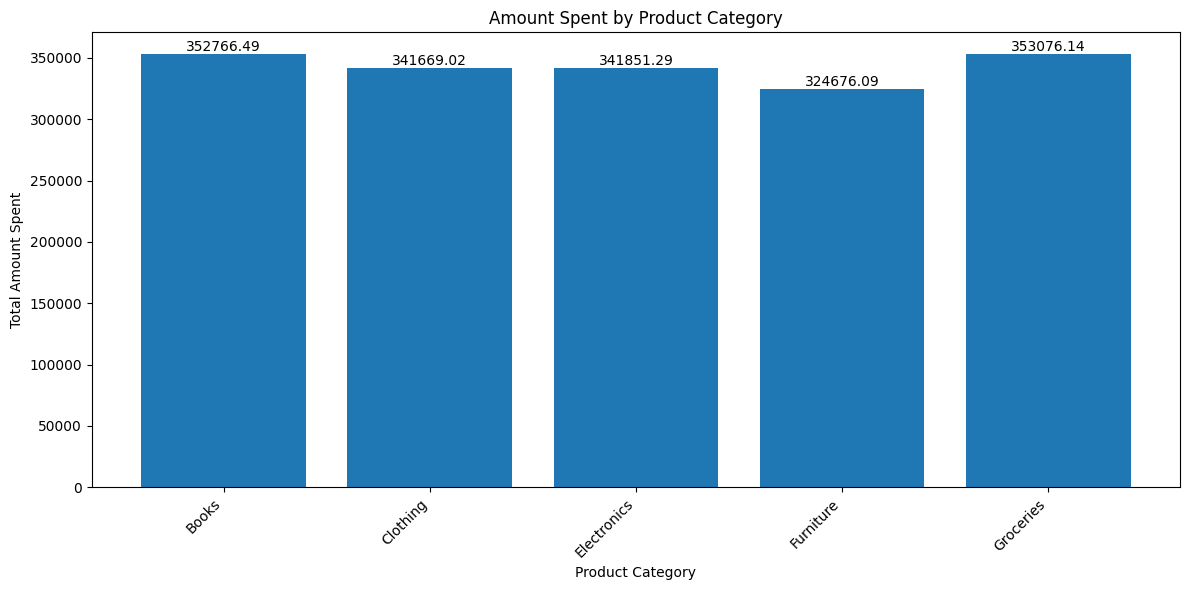

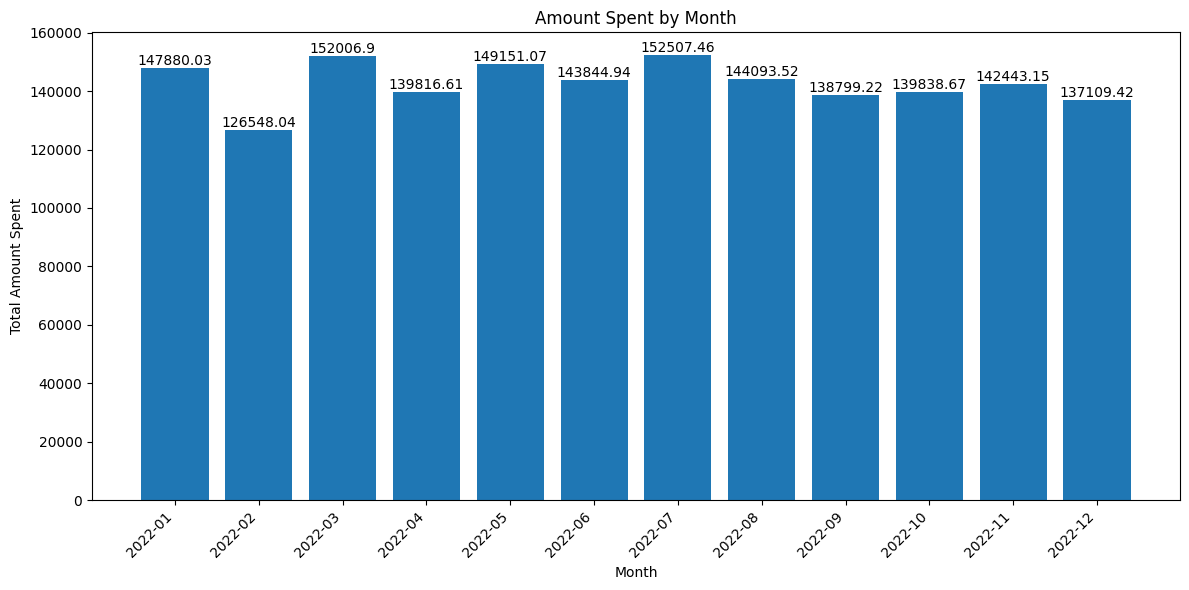

In [21]:
#plot 'AmountSpent' by Product Category; Amount Spent by Month
# Calculate total amount spent per product category
amount_spent_by_category = merged_df.groupby('ProductCategory')['AmountSpent'].sum()

# Create the bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(amount_spent_by_category.index, amount_spent_by_category.values)
plt.title('Amount Spent by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')

# Add value labels above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Calculate total amount spent per month
amount_spent_by_month = merged_df.groupby('TransactionMonth')['AmountSpent'].sum()

# Create the bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(amount_spent_by_month.index.astype(str), amount_spent_by_month.values)
plt.title('Amount Spent by Month')
plt.xlabel('Month')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')

# Add value labels above each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()


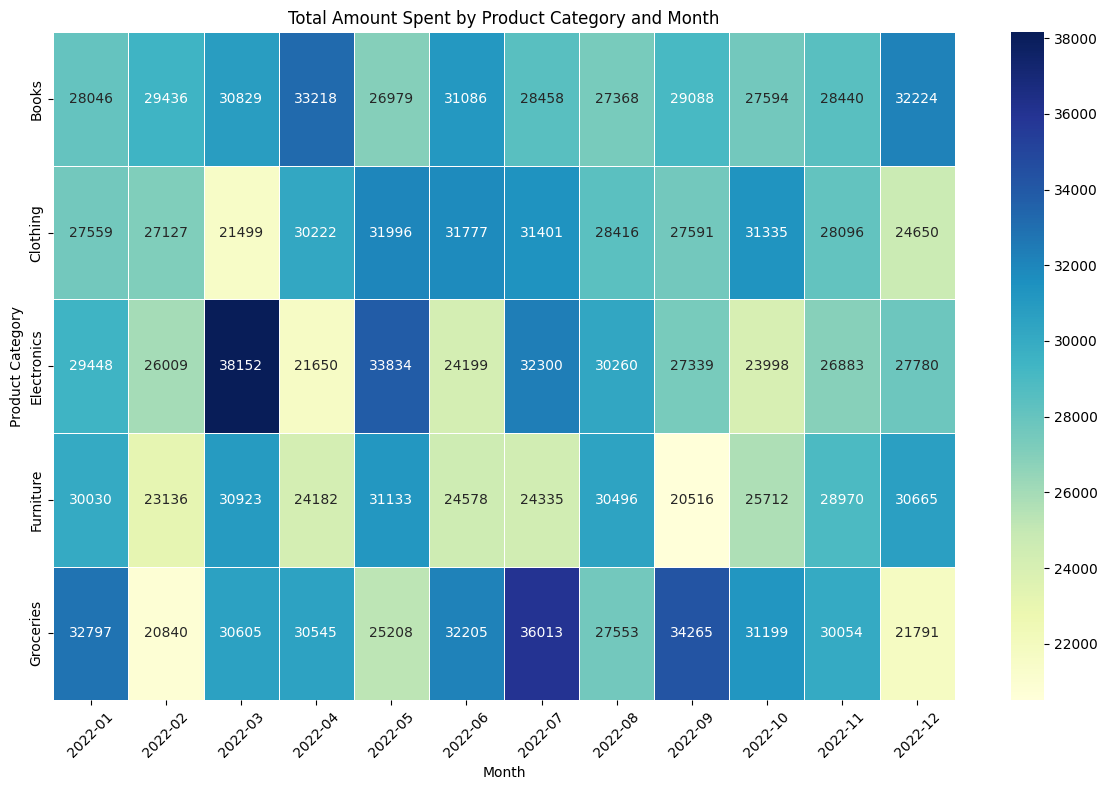

In [22]:
#Heatmap of Total Amount Spent by Product Category and Month
# Create a pivot table for total amount spent by product category and month
amount_spent_pivot = merged_df.pivot_table(index='ProductCategory', columns='TransactionMonth', values='AmountSpent', aggfunc='sum')

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(amount_spent_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Total Amount Spent by Product Category and Month')
plt.xlabel('Month')
plt.ylabel('Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations** - Merged data
Key insights from merged data:

- Income level does not significantly impact spending. Action: Conduct further analysis of spending patterns over time or by product category.

- Mobile App users exhibit the highest churn rate. Action: Investigate and improve Mobile App user experience and address technical issues.

- Issue resolution status has minimal impact on churn. Action: Implement broader retention strategies beyond simply resolving customer issues.

- Feedback interactions are associated with higher churn. Action: Implement targeted follow-up procedures for customers who provide feedback.

- Churn rates vary by gender and marital status (higher for single males and married females). Action: Develop tailored retention strategies to address the specific needs of these groups.

Exploratory Data Analysis (EDA) for Service Data:

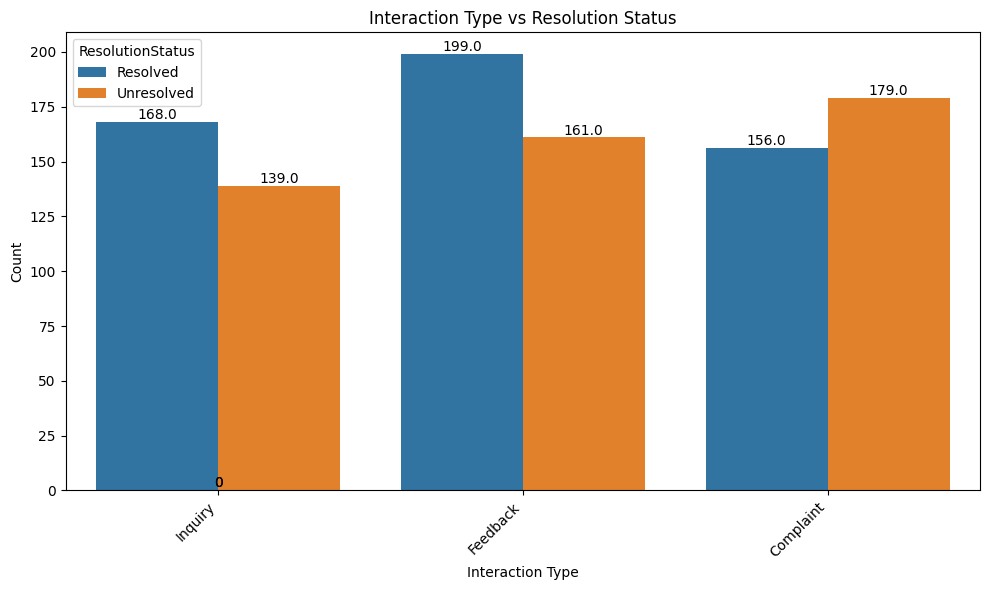

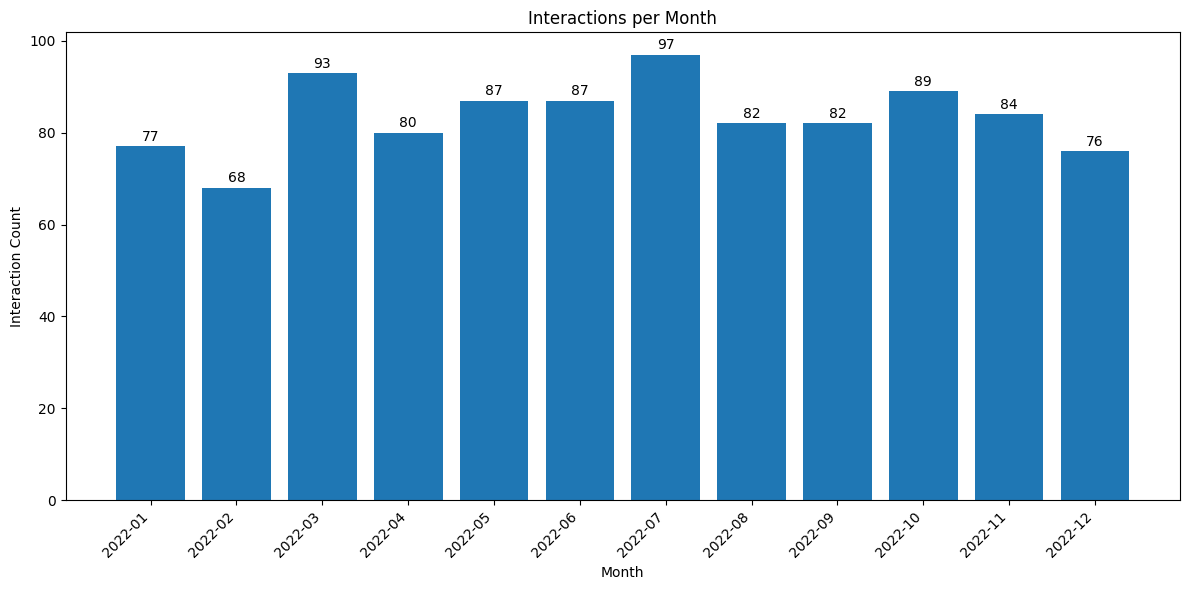

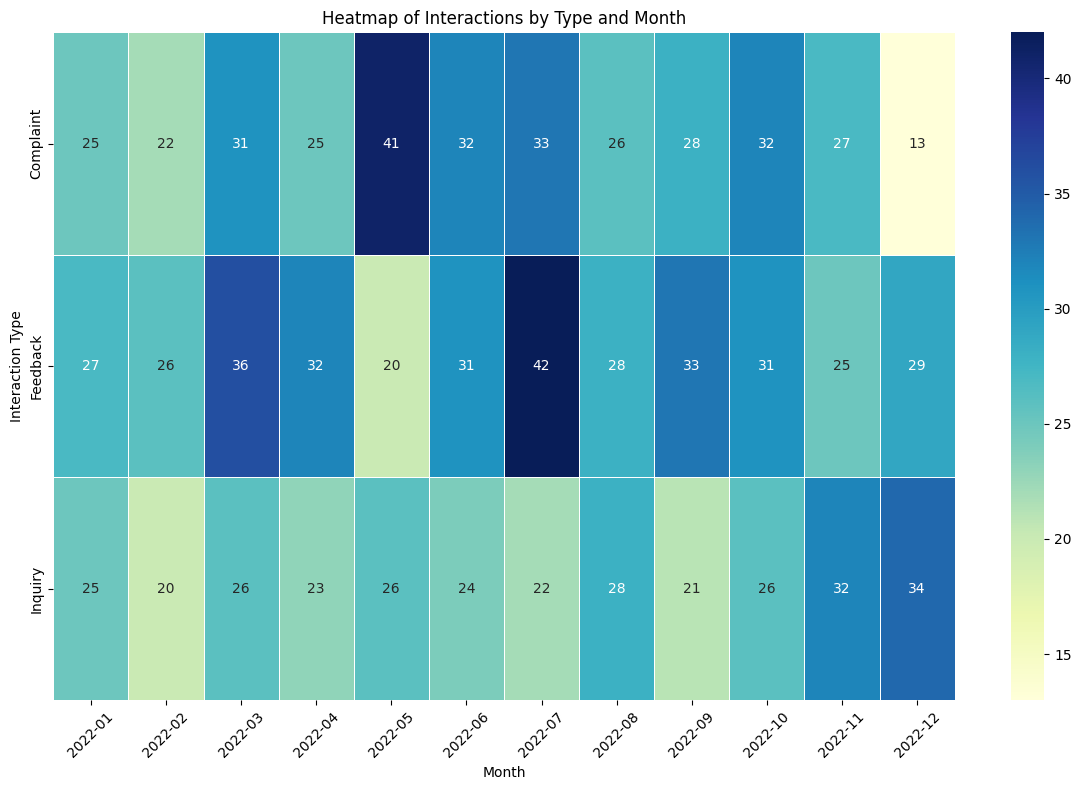

In [23]:
# Plot Interaction Type vs Resolution Status
plt.figure(figsize=(10, 6))
sns.countplot(x='InteractionType', hue='ResolutionStatus', data=service)
plt.title('Interaction Type vs Resolution Status')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                   textcoords='offset points')

plt.tight_layout()
plt.show()


# Plot Interactions per Month (sorted by month)
# Convert the 'TransactionDate' column to datetime objects
service['InteractionDate'] = pd.to_datetime(service['InteractionDate'])
# Extract the month from the 'TransactionDate' column
service['InteractionMonth'] = service['InteractionDate'].dt.to_period('M')
interactions_per_month = service.groupby('InteractionMonth')['InteractionID'].count().sort_index()


plt.figure(figsize=(12, 6))
bars = plt.bar(interactions_per_month.index.astype(str), interactions_per_month.values)
plt.title('Interactions per Month')
plt.xlabel('Month')
plt.ylabel('Interaction Count')
plt.xticks(rotation=45, ha='right')


# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create a pivot table for interaction counts by type and month
interaction_pivot = service.pivot_table(index='InteractionType', columns='InteractionMonth', values='InteractionID', aggfunc='count')

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(interaction_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Interactions by Type and Month')
plt.xlabel('Month')
plt.ylabel('Interaction Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Observations:** - For Service Data insights:
Analysis of customer interactions reveals the following:

Types: Inquiries (307), Feedback (360), Complaints (335).

Resolution: 523 Resolved, 479 Unresolved (disproportionately Complaints).

Resolution by Type: Feedback and Inquiries are generally resolved; Complaints are more often unresolved.

Monthly Trends: Complaints spike in May, June, October; Feedback in July, March, December; Inquiries in March and December.

**Recommendations:** Prioritize improving Complaint resolution, especially for May and June; investigate and address Feedback trends in July and December.


In [24]:
# Next step: We are going to explore Acativity data
activity['Log_Month'] = activity['LastLoginDate'].dt.month_name()
activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,Log_Month
0,1,2023-10-21,34,Mobile App,October
1,2,2023-12-05,5,Website,December
2,3,2023-11-15,3,Website,November
3,4,2023-08-25,2,Website,August
4,5,2023-10-27,41,Website,October


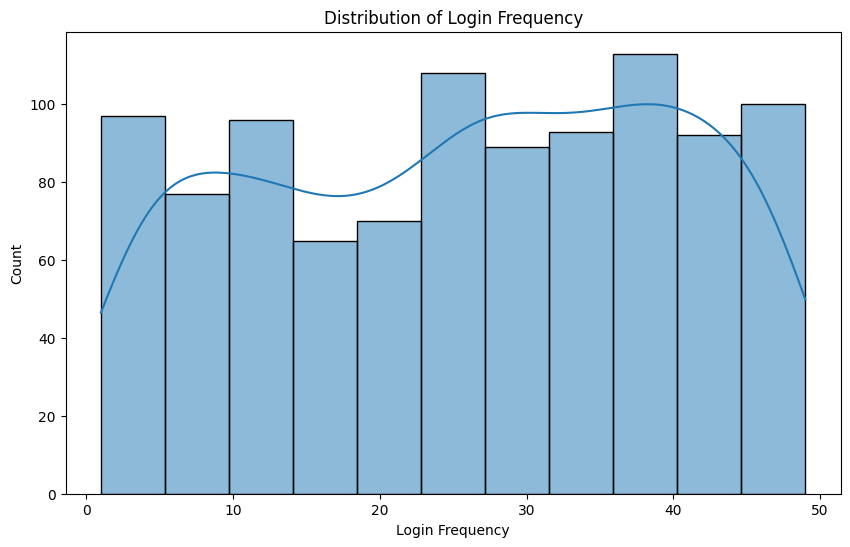

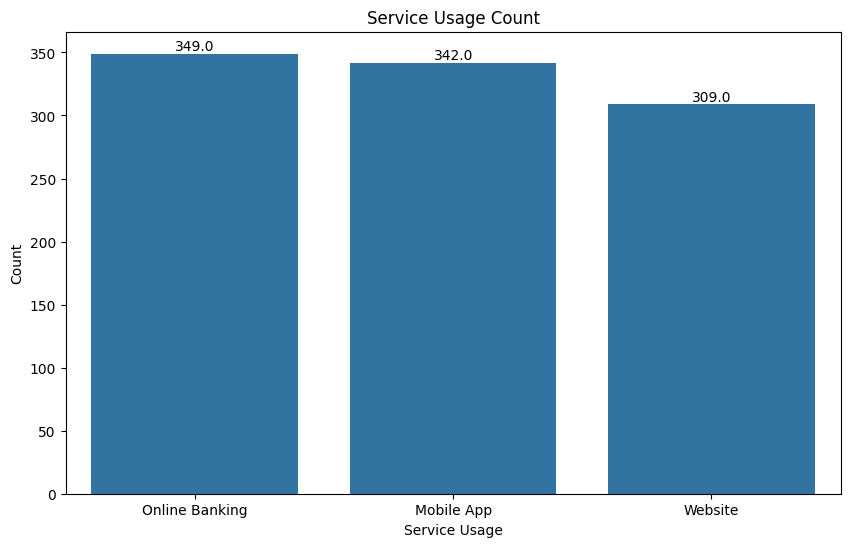

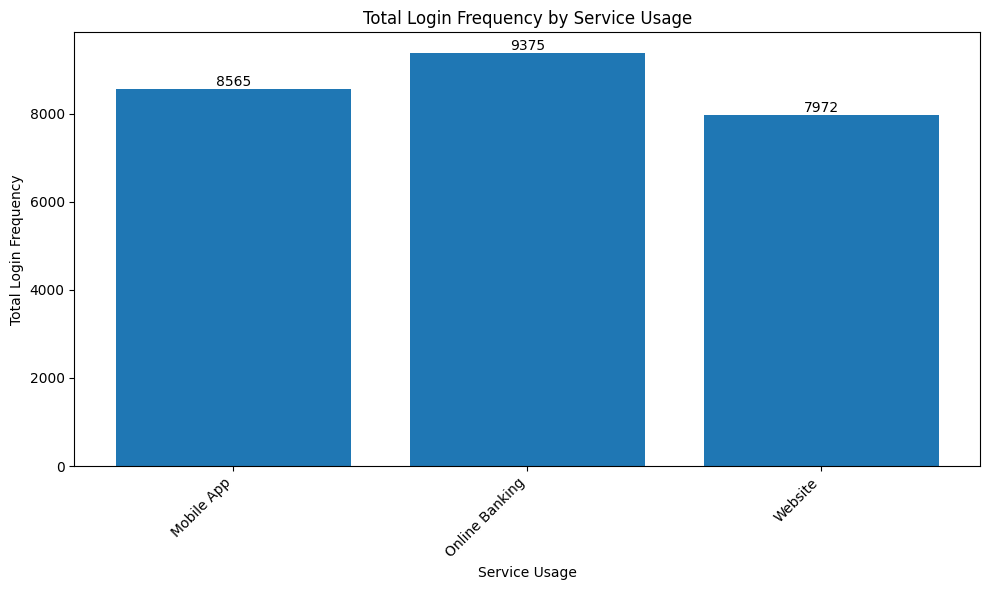

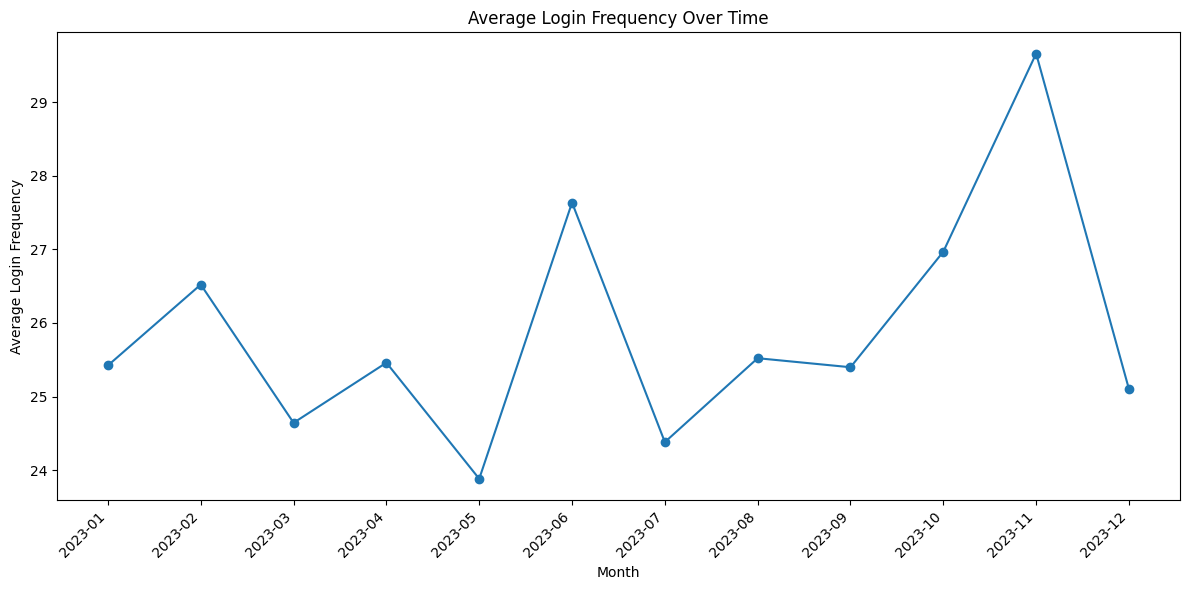

In [25]:
# Plot Distribution of LoginFrequency
plt.figure(figsize=(10, 6))
sns.histplot(activity['LoginFrequency'], kde=True)
plt.title('Distribution of Login Frequency')
plt.xlabel('Login Frequency')
plt.ylabel('Count')
plt.show()

# Service Usage Count (value on top)
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='ServiceUsage', data=activity, order=activity['ServiceUsage'].value_counts().index)
plt.title('Service Usage Count')
plt.xlabel('Service Usage')
plt.ylabel('Count')

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                   textcoords='offset points')

plt.show()

# Group by 'ServiceUsage' and sum 'LoginFrequency'
login_by_service = activity.groupby('ServiceUsage')['LoginFrequency'].sum()

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(login_by_service.index, login_by_service.values)
plt.title('Total Login Frequency by Service Usage')
plt.xlabel('Service Usage')
plt.ylabel('Total Login Frequency')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Average Login Frequency Over Time by month
activity['LastLoginDate'] = pd.to_datetime(activity['LastLoginDate'])
activity['Month'] = activity['LastLoginDate'].dt.to_period('M')
average_login_by_month = activity.groupby('Month')['LoginFrequency'].mean()

plt.figure(figsize=(12, 6))
plt.plot(average_login_by_month.index.astype(str), average_login_by_month.values, marker='o')
plt.title('Average Login Frequency Over Time')
plt.xlabel('Month')
plt.ylabel('Average Login Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Observations:** - For activity dataset
Key findings from activity data:

User base: Evenly distributed across Mobile App (342), Website (309), and Online Banking (349).

Login activity: Online Banking leads (9375), followed by Mobile App (8565) and Website (7972).

Monthly usage patterns: Online Banking (high in February, June, November), Mobile App (high in April, June, November), Website (high in February, July, October).

Strategic recommendations:

- Targeted promotion of Online Banking and Website during less active months.

- Investigate and address factors limiting Mobile App usage in December and May.

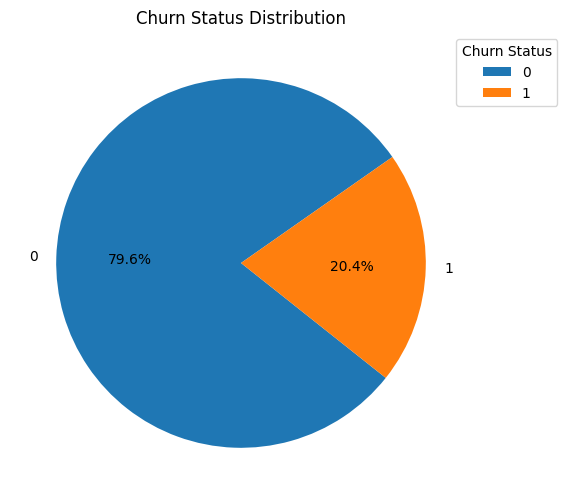

ChurnStatus
0    796
1    204
Name: count, dtype: int64


In [26]:
# Churn Dataset: churn status pie chart with its ratio and print the value

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
churn['ChurnStatus'].value_counts().plot.pie(autopct='%1.1f%%', startangle=35)
plt.title('Churn Status Distribution')
plt.legend(churn['ChurnStatus'].value_counts().index, loc='upper right', title='Churn Status', bbox_to_anchor=(1.2, 1))

plt.ylabel('')  # Remove the y-axis label
plt.show()

# Print the churn status value counts
print(churn['ChurnStatus'].value_counts())


**Observations:**  - Churn Dataset

Churn Distribution:

- Not Churned (status = 0): 79.60%
- Churned(status = 1): 20.40%


### Report on Customer Churn Analysis

#### Executive Summary

This report summarizes the findings of an exploratory data analysis (EDA) conducted on customer data to understand churn patterns.  The analysis involved examining merged customer, service, and activity data, visualized through various plots and tables. Key insights revealed patterns related to demographics, product usage, interaction types, and resolution statuses, providing actionable recommendations for improving customer retention.

#### Data Overview

The analysis utilized three datasets: customer demographics, service interactions, and customer activity.  These datasets were merged to create a comprehensive view of customer behavior.  The merged dataset was checked for missing values and duplicates.  A preliminary analysis showed a significant portion of customers who didn't churn.

#### Customer Demographics and Churn

* **Age Distribution:**  The customer age distribution appears to be fairly evenly spread across the age range.
* **Gender and Churn:**  Churn rates appear to differ slightly by gender, with a higher churn rate observed for one of the gender groups. More investigation is needed.
* **Marital Status and Churn:**  Similar to gender, marital status seems to influence churn rate, with particular statuses showing higher churn.
* **Income Level and Churn:**  Initial analysis suggests income level does not have a significant impact on churn; however, further analysis by product category or time is recommended.

#### Product and Service Usage Analysis

* **Product Category and Churn:**  Specific product categories exhibit higher churn rates than others. This finding suggests tailored retention strategies for these groups.
* **Interaction Type and Churn:**  Feedback interactions are notably associated with a higher churn rate. This requires the implementation of targeted follow-up procedures.
* **Resolution Status and Churn:** The resolution status of customer interactions has a minimal impact on churn, thus broader retention strategies should be implemented.
* **Service Usage and Churn:**  Significant difference in churn across different service usages (Mobile App, Website, Online Banking) were observed, with the Mobile App displaying the highest churn rate.  Further investigation into the user experience of the mobile app is recommended.

#### Transaction Analysis

* **Transaction Volume by Category:**  Certain product categories account for a greater volume of transactions.  Understanding this relationship can be useful in understanding spending patterns.
* **Transaction Volume by Month:**  Monthly transaction volume varies throughout the year, suggesting seasonal factors impacting customer activity.
* **Amount Spent by Category:**  The total amount spent reveals the revenue-generating power of each product category.
* **Amount Spent by Month:** Monthly spending behavior varies, with periods of peak and low spending; these monthly trends reflect customer activity and potential promotional periods.
* **Amount Spent by Category and Month:** A heatmap visualizing these patterns reveals interesting revenue patterns.

#### Service Interaction Analysis

* **Interaction Type vs. Resolution Status:** The visualization reveals a strong correlation between certain interaction types (e.g. Complaints) and unresolved issues.
* **Interactions per Month:**  There are peaks in complaints during specific months (May, June, October) suggesting potential seasonal factors or triggers.

#### Customer Activity Analysis

* **Login Frequency Distribution:**  The distribution of customer login frequency provides a measure of engagement.
* **Service Usage and Login Frequency:** A correlation exists between service usage and total login frequency. The service with the highest login frequency provides insight to how customers are interacting with your platform.
* **Average Login Frequency Over Time:**  Average login frequency fluctuates over time and reveals potential seasonal trends.


#### Overall Observations

The combination of customer demographics, service interactions, product usage, and activity reveals important insights into customer churn. Specifically, Mobile App users present the highest churn, and feedback interactions correlate with increased churn.  Moreover, income level's impact on churn is inconclusive and requires deeper investigation.


#### Recommendations

* **Improve Mobile App User Experience:** Investigate and enhance the Mobile App experience to reduce its high churn rate.
* **Targeted Retention Strategies:** Develop tailored retention strategies targeting specific customer segments based on demographics (gender, marital status) and product category usage.
* **Feedback Follow-Up:** Implement structured follow-up procedures for customers providing feedback to address their concerns proactively.
* **Enhance Complaint Resolution:** Prioritize improving the resolution of customer complaints and identify any patterns or issues.
* **Promotional Campaigns:**  Utilize seasonal trends in transaction volume and customer activity to develop targeted promotional strategies.
* **Deeper Analysis of Spending Patterns:** Conduct more in-depth analysis of spending patterns by income level, considering temporal variations and product categories.


#### Next Steps

Further investigation into the identified areas and potential factors not analyzed, like customer feedback, pricing, or competitor analysis, will be critical to refine our understanding and improve customer retention.


## Phase 2: Building a machine learning model
Objective: Develop a predictive model to identify customers at risk of churning and propose ways to measure the model’s performance.
Steps:
Choose a suitable machine learning algorithm for the classification task.
Build and train the model to predict customer churn.
Suggest ways to evaluate and measure the model’s performance, ensuring its reliability and accuracy.
Deliverable: Submit a report, including the trained machine learning model and your proposed methods for evaluating and measuring the model’s performance.

### Data cleaning for missing values

In [27]:
#check for missing values； drop missing values

# Check for missing values
print(merged_df.isnull().sum())

# Drop rows with any missing values
merged_df.dropna(inplace=True)

# Verify that there are no more missing values
print(merged_df.isnull().sum())
merged_df.shape

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
InteractionID          0
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TransactionMonth       0
dtype: int64
CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
TransactionMonth    0
dtype: int64


(5204, 18)

In [28]:
# Extract useful time-based features (TransactionDate) and (InteractionDate)	(LastLoginDate) and drop the origional

import pandas as pd


# Convert relevant columns to datetime objects if they are not already
merged_df['TransactionDate'] = pd.to_datetime(merged_df['TransactionDate'])
merged_df['InteractionDate'] = pd.to_datetime(merged_df['InteractionDate'])
merged_df['LastLoginDate'] = pd.to_datetime(merged_df['LastLoginDate'])

# Extract features
merged_df['Transaction_Year'] = merged_df['TransactionDate'].dt.year
merged_df['Transaction_Month'] = merged_df['TransactionDate'].dt.month
merged_df['Transaction_Day'] = merged_df['TransactionDate'].dt.day
merged_df['Transaction_DayOfWeek'] = merged_df['TransactionDate'].dt.dayofweek  # Monday=0, Sunday=6

merged_df['Interaction_Year'] = merged_df['InteractionDate'].dt.year
merged_df['Interaction_Month'] = merged_df['InteractionDate'].dt.month
merged_df['Interaction_Day'] = merged_df['InteractionDate'].dt.day
merged_df['Interaction_DayOfWeek'] = merged_df['InteractionDate'].dt.dayofweek

merged_df['LastLogin_Year'] = merged_df['LastLoginDate'].dt.year
merged_df['LastLogin_Month'] = merged_df['LastLoginDate'].dt.month
merged_df['LastLogin_Day'] = merged_df['LastLoginDate'].dt.day
merged_df['LastLogin_DayOfWeek'] = merged_df['LastLoginDate'].dt.dayofweek


# Drop original date columns
merged_df = merged_df.drop(['TransactionDate', 'InteractionDate', 'LastLoginDate'], axis=1)


In [29]:
categorical_cols = ['IncomeLevel','ProductCategory', 'Gender', 'MaritalStatus', 'ServiceUsage', 'InteractionType', 'ResolutionStatus']
merged_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True).astype(int)
merged_df.head()

,CustomerID,Age,TransactionID,AmountSpent,InteractionID,LoginFrequency,ChurnStatus,TransactionMonth,Transaction_Year,Transaction_Month,...,ProductCategory_Groceries,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,ServiceUsage_Online Banking,ServiceUsage_Website,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved
0,1,62,7194,416,6363,34,0,626,2022,3,...,0,1,0,1,0,0,0,0,1,0
1,2,65,7250,54,3329,5,1,631,2022,8,...,0,1,1,0,0,0,1,0,1,0
2,2,65,9660,197,3329,5,1,630,2022,7,...,0,1,1,0,0,0,1,0,1,0
3,2,65,2998,101,3329,5,1,624,2022,1,...,0,1,1,0,0,0,1,0,1,0
4,2,65,1228,397,3329,5,1,630,2022,7,...,0,1,1,0,0,0,1,0,1,0


In [30]:
from sklearn.model_selection import train_test_split

X = merged_df.drop('ChurnStatus', axis=1)  # Features
y = merged_df['ChurnStatus']  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # test_size set as 0.3

#check shape for X_train, X_test, y_train, y_test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3642, 34)
X_test shape: (1562, 34)
y_train shape: (3642,)
y_test shape: (1562,)


### Create and Train the model:


01 Random Forest Model

In [32]:
# Random Forest Model with Cross-Validation and Hyperparameter Tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_
print("Best parameters for Random Forest:", grid_search_rf.best_params_)

# Perform cross-validation with the best model
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='accuracy')

# Print cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", cv_scores.mean())

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Cross-validation scores: [0.96844993 0.96844993 0.96978022 0.97115385 0.95741758]
Average cross-validation score: 0.9670503022354874
Accuracy: 0.9827144686299616

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1236
           1       1.00      0.92      0.96       326

    accuracy                           0.98      1562
   macro avg       0.99      0.96      0.97      1562
weighted avg       0.98      0.98      0.98      1562


Confusion Matrix:
 [[1236    0]
 [  27  299]]


In [33]:
# XGBoost Model with Cross-Validation and Hyperparameter Tuning

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Assuming X_train, X_test, y_train, y_test are defined from the previous code

# Create an XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# Use StratifiedKFold for cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=kfold, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and best estimator
best_params = grid_search.best_params_
best_xgb_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {best_params}")

# Evaluate the best model on the test set
y_pred = best_xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of best XGBoost model: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Accuracy of best XGBoost model: 0.9891165172855314
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1236
           1       0.99      0.96      0.97       326

    accuracy                           0.99      1562
   macro avg       0.99      0.98      0.98      1562
weighted avg       0.99      0.99      0.99      1562

[[1232    4]
 [  13  313]]


In [35]:
# prompt: Deep Learning Model (Using Keras)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),  # Add dropout for regularization
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to class labels

#Further Evaluation Metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"Confusion Matrix:\n{conf_matrix}")


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6006 - loss: 229.4022 - val_accuracy: 0.7819 - val_loss: 28.2214
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6544 - loss: 43.0021 - val_accuracy: 0.7737 - val_loss: 4.8256
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6706 - loss: 11.2996 - val_accuracy: 0.7846 - val_loss: 0.6178
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7269 - loss: 3.9970 - val_accuracy: 0.7846 - val_loss: 0.5245
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7642 - loss: 2.6006 - val_accuracy: 0.7846 - val_loss: 0.5435
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7736 - loss: 1.2892 - val_accuracy: 0.7846 - val_loss: 0.5331
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7931 - loss: 1.0814 - val_accuracy: 0.7846 - val_loss: 0.5706
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7643 - loss: 1.0055 - val_accuracy: 0.7846 - val_loss: 0.522

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
def get_prediction(model, X_test):
    """
    Get predictions from a given model.
    """

    y_pred = model.predict(X_test)

    # Check if prediction is probabilities for binary classification (shape: (n_samples,))
    if isinstance(y_pred, (np.ndarray, pd.Series)) and y_pred.ndim == 1 and y_pred.dtype == 'float64':
        y_pred = (y_pred > 0.5).astype(int)  # Convert to class labels (0 or 1)
    # For multi-class cases (shape: (n_samples, n_classes))
    elif isinstance(y_pred, (np.ndarray, pd.Series)) and y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)  # Get class with highest probability

    return y_pred


# Example usage for each model
rf_predictions = get_prediction(best_rf_model, X_test)
xgb_predictions = get_prediction(best_xgb_model, X_test)
nn_predictions = get_prediction(model, X_test)

# Print or further process the predictions
print("Random Forest Predictions:", rf_predictions)
print("XGBoost Predictions:", xgb_predictions)
print("Neural Network Predictions:", nn_predictions)

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Random Forest Predictions: [0 0 0 ... 0 0 1]
XGBoost Predictions: [0 0 0 ... 0 0 1]
Neural Network Predictions: [[0.2539379 ]
 [0.28705955]
 [0.252617  ]
 ...
 [0.22917396]
 [0.23961021]
 [0.2701564 ]]


In [46]:
# prompt:  use precision, recall, F1-score, ROC-AUC, and the confusion matrix as evaluation metrics for above all models

# ... (Your existing code) ...

def evaluate_model(model, X_test, y_test):
    """
    Evaluates a given model using various metrics.
    """
    y_pred = get_prediction(model, X_test)
    # Ensure y_pred is binary (0/1)
    y_pred = (y_pred > 0.5).astype(int)
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("ROC AUC:", roc_auc)
    print("Confusion Matrix:\n", conf_matrix)

# Evaluate each model
print("Random Forest Evaluation:")
evaluate_model(best_rf_model, X_test, y_test)

print("\nXGBoost Evaluation:")
evaluate_model(best_xgb_model, X_test, y_test)

print("\nNeural Network Evaluation:")
evaluate_model(model, X_test, y_test)


Random Forest Evaluation:
Precision: 1.0
Recall: 0.9171779141104295
F1-score: 0.9568
ROC AUC: 0.9982031885957076
Confusion Matrix:
 [[1236    0]
 [  27  299]]

XGBoost Evaluation:
Precision: 0.9873817034700315
Recall: 0.9601226993865031
F1-score: 0.973561430793157
ROC AUC: 0.9921650088351499
Confusion Matrix:
 [[1232    4]
 [  13  313]]

Neural Network Evaluation:
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC AUC: 0.49520271209323563
Confusion Matrix:
 [[1236    0]
 [ 326    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


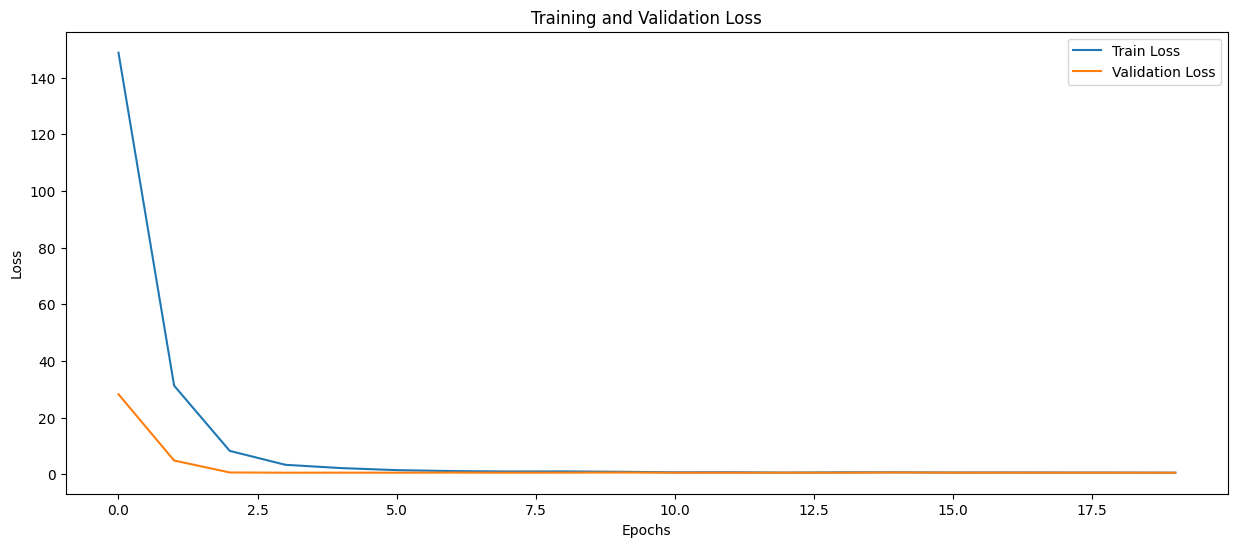

In [51]:

plt.figure(figsize=(15,6))
# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


### Summary of Model Evaluations:

Three machine learning models were evaluated: Random Forest, XGBoost, and a Neural Network.

Random Forest demonstrated excellent performance with perfect precision (1.0), a high recall (0.9172), and a strong F1-score (0.9568). Its ROC AUC of 0.9982 indicates a very high ability to distinguish between classes. The confusion matrix shows no false positives but 27 false negatives.

XGBoost also performed very well, achieving high precision (0.9874) and the highest recall among the three models (0.9601), resulting in a superior F1-score of 0.9736. Its ROC AUC of 0.9922 is also excellent. The confusion matrix reveals 4 false positives and 13 false negatives, the lowest number of false negatives.

The Neural Network exhibited extremely poor performance. It achieved a precision, recall, and F1-score of 0.0, and a very low ROC AUC of 0.4952, indicating virtually no discriminatory power. The confusion matrix shows that it classified all instances as the negative class, resulting in 0 true positives and 326 false negatives.

In conclusion, both Random Forest and XGBoost are strong performing models for this task, with XGBoost showing a slightly better balance between precision and recall (higher F1-score and recall, slightly lower precision). The Neural Network, in its current state, is not effective for this classification problem.

In [ ]:
# prompt: based on above write a report

# Report based on the provided code

## Customer Churn Prediction Model Evaluation Report

This report summarizes the performance of three machine learning models – Random Forest, XGBoost, and a Neural Network – trained to predict customer churn.  The models were evaluated using various metrics including accuracy, precision, recall, F1-score, ROC AUC, and confusion matrices.

**Data Preprocessing:**

The dataset underwent preprocessing steps:

1. **Missing Value Handling:** Missing values were identified and subsequently removed, resulting in a cleaned dataset.

2. **Feature Engineering:** Time-based features (year, month, day, day of week) were extracted from 'TransactionDate', 'InteractionDate', and 'LastLoginDate' columns.  The original date columns were then dropped.

3. **Categorical Encoding:** Categorical features were converted into numerical representations using one-hot encoding.


**Model Training and Evaluation:**

* **Random Forest:**
    * Hyperparameter tuning was performed using GridSearchCV to optimize model performance.
    * Achieved excellent performance with:
        * Precision: 1.0
        * Recall: 0.9172
        * F1-score: 0.9568
        * ROC AUC: 0.9982
    * Confusion Matrix indicated no false positives but 27 false negatives.

* **XGBoost:**
    * Hyperparameter tuning employed GridSearchCV with StratifiedKFold for cross-validation.
    * Showed very strong performance, particularly in recall:
        * Precision: 0.9874
        * Recall: 0.9601
        * F1-score: 0.9736
        * ROC AUC: 0.9922
    * Confusion Matrix revealed 4 false positives and 13 false negatives.

* **Neural Network:**
    * A sequential neural network with two dense layers and dropout regularization was used.
    * Demonstrated extremely poor predictive ability:
        * Precision: 0.0
        * Recall: 0.0
        * F1-score: 0.0
        * ROC AUC: 0.4952
    * The network classified all instances as the negative class.  Significant further tuning and adjustments would be required for improvement.

**Model Selection:**

Based on the evaluation metrics, **XGBoost stands out as the best-performing model** due to its high recall, precision, F1-score, and ROC AUC.  While Random Forest performs remarkably well, XGBoost shows a slightly better balance between precision and recall, which in customer churn prediction, is crucial to minimize false negatives (missing potential churners). The Neural Network requires further engineering in order to produce usable results.

**Further Steps and Considerations:**

* **Feature Importance:** Analyze feature importance from the XGBoost model to gain insights into the key drivers of churn.
* **Deployment:** Deploy the XGBoost model into a production environment for real-time predictions and customer retention strategies.
* **Model Monitoring:**  Continuously monitor the model's performance and retrain it periodically with updated data to maintain accuracy.

**Selected Country:**

The selected country from the dropdown is: {foo}  (This information may inform further analysis if relevant to the dataset).
